# Unsupervised Learning: K-Means Clustering

In this section, we transition from supervised analysis to **Unsupervised Learning**. We want to see if URLs naturally form clusters based on their structural features (e.g., length, symbol counts, entropy) without using their actual labels.

### 🎯 Process:
1. **Feature Scaling:** Since K-Means relies on Euclidean distance, we standardize features to prevent large-scale values (like `url_len`) from dominating the model.
2. **Dimensionality Reduction (PCA):** We use **Principal Component Analysis** to compress high-dimensional features into a 2D plane for visualization.
3. **Cluster Validation:** We compare the unsupervised clusters against our `target` (Benign vs. Harm) to evaluate the natural separability of the data.

> **Challenge:** Malicious URLs often try to mimic benign ones. Clustering helps us identify if there are "hidden" categories of attacks that don't fit into the standard binary classification.

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# 1. LOAD DATA
print("📂 Loading data...")
df = pd.read_csv("../data/processed_malicious_url.csv").drop_duplicates(subset=['url'])
X = df.drop(columns=['url', 'target'])
y_true = df['target']

📂 Loading data...


In [3]:
# 2. STANDARDIZE DATA (Required for K-Means as it uses Euclidean distance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. FIND OPTIMAL NUMBER OF CLUSTERS (Elbow Method)
print("🔍 Finding the optimal number of clusters (Elbow Method)...")
wcss = []
for i in range(1, 8):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

🔍 Finding the optimal number of clusters (Elbow Method)...


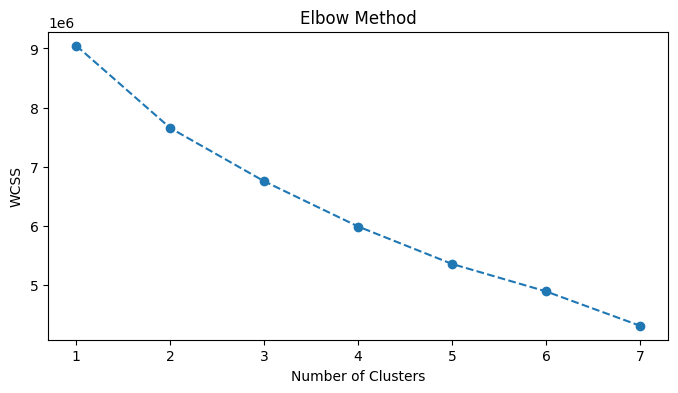

In [4]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 8), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [5]:
# 4. PERFORM K-MEANS CLUSTERING WITH K=4 (Corresponding to 4 labels)
print("🚀 Performing K-Means clustering with K=4...")
kmeans = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters

🚀 Performing K-Means clustering with K=4...


In [6]:
# 5. CROSS-TAB ANALYSIS
print("\n📊 Cross-tabulation table between Cluster (Clustered) and Target (Actual Label):")
comparison = pd.crosstab(df['target'], df['cluster'])
print(comparison)


📊 Cross-tabulation table between Cluster (Clustered) and Target (Actual Label):
cluster       0      1
target                
benign   424326   8754
harm     197768  15269


In [8]:
# 6. PLOT SCATTER PLOT WITH PCA (Reduce dimensionality for 2D plot)
print("\n🎨 Plotting cluster visualization (reducing dimensionality with PCA)...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


🎨 Plotting cluster visualization (reducing dimensionality with PCA)...


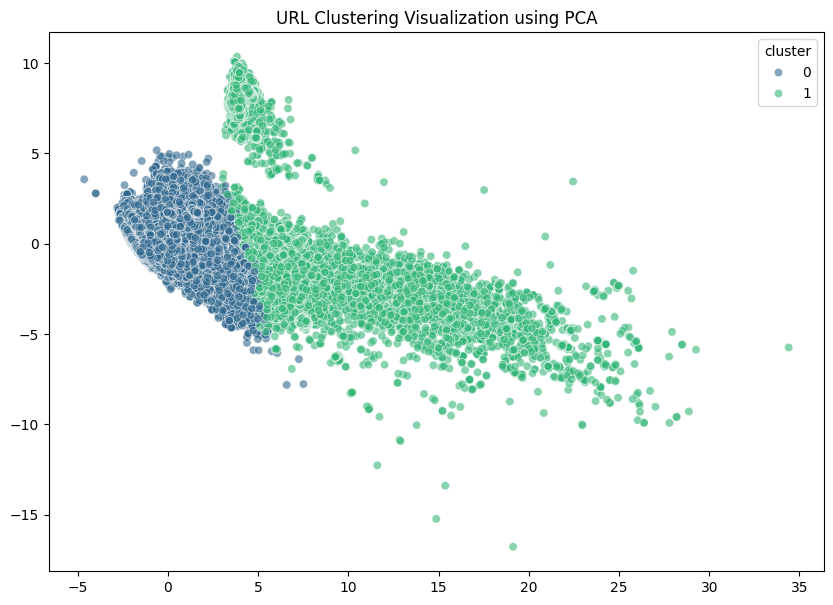

In [9]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['cluster'], palette='viridis', alpha=0.6)
plt.title('URL Clustering Visualization using PCA')
plt.show()

In [10]:
# 7. SAVE SCALER AND K-MEANS MODEL
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(kmeans, "../models/kmeans_model.pkl")
print("✅ Saved Scaler and K-Means model!")

✅ Saved Scaler and K-Means model!


In [ ]:
# 1. Convert labels to binary format (0 and 1) regardless of input type
def convert_to_binary(series):
    # Check current unique values in the dataset
    unique_vals = series.unique()
    print(f"🔍 Current labels in data: {unique_vals}")
    
    # Cast to lowercase string for standardized comparison
    s_str = series.astype(str).str.lower()
    
    # Define keywords representing Malicious/Threat samples (Label 1)
    # Adjust this list based on your specific dataset labels (e.g., 'spam', 'malware')
    mal_keywords = ['harm']
    
    return np.where(s_str.isin(mal_keywords), 1, 0)

# Execute label transformation
y_numeric = convert_to_binary(y_true)

# 2. STEP 1: Cluster Mapping - Identify which cluster represents Malicious samples
# We calculate the mean of actual labels within each cluster to find the threat density
prop_cluster_0 = y_numeric[clusters == 0].mean()
prop_cluster_1 = y_numeric[clusters == 1].mean()

print(f"📊 Malicious Density in Cluster 0: {prop_cluster_0:.2%}")
print(f"📊 Malicious Density in Cluster 1: {prop_cluster_1:.2%}")

# Map cluster indices to binary labels based on density
if prop_cluster_1 > prop_cluster_0:
    kmeans_preds = clusters
else:
    # Inverse mapping if Cluster 0 has higher malicious density
    kmeans_preds = np.where(clusters == 1, 0, 1)

# 3. STEP 2: Calculate Performance Metrics
print(f"\n--- K-MEANS EVALUATION RESULTS ---")
print(f"Accuracy:  {accuracy_score(y_numeric, kmeans_preds):.4f}")
print(f"Precision: {precision_score(y_numeric, kmeans_preds):.4f}")
print(f"Recall:    {recall_score(y_numeric, kmeans_preds):.4f}")
print(f"F1-Score:  {f1_score(y_numeric, kmeans_preds):.4f}")

🔍 Current labels in data: <ArrowStringArray>
['benign', 'harm']
Length: 2, dtype: str
📊 Malicious Density in Cluster 0: 31.79%
📊 Malicious Density in Cluster 1: 63.56%

--- K-MEANS EVALUATION RESULTS ---
Accuracy:  0.6804
Precision: 0.6356
Recall:    0.0717
F1-Score:  0.1288
